In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./pageViews.csv',parse_dates=True)
df['date'] = pd.to_datetime(df['date'])

## Data Cleaning

In [3]:
upper_limit = df['value'] < df['value'].quantile(0.975)
low_limit = df['value'] >= df['value'].quantile(0.025)

In [4]:
df_c = df.loc[upper_limit & low_limit]

##Ploting

In [5]:
df_month = df_c

# df_month['date'] = df_month['date']
# df_month['date'] = pd.to_datetime(df_month['date'],format='%Y%m' )
# group = df_month.groupby(pd.Grouper(key='date',freq='MS'))

In [6]:
df_month = df_month.set_index('date')
#Aqui esta la clave para que las  fechas salgan bien.

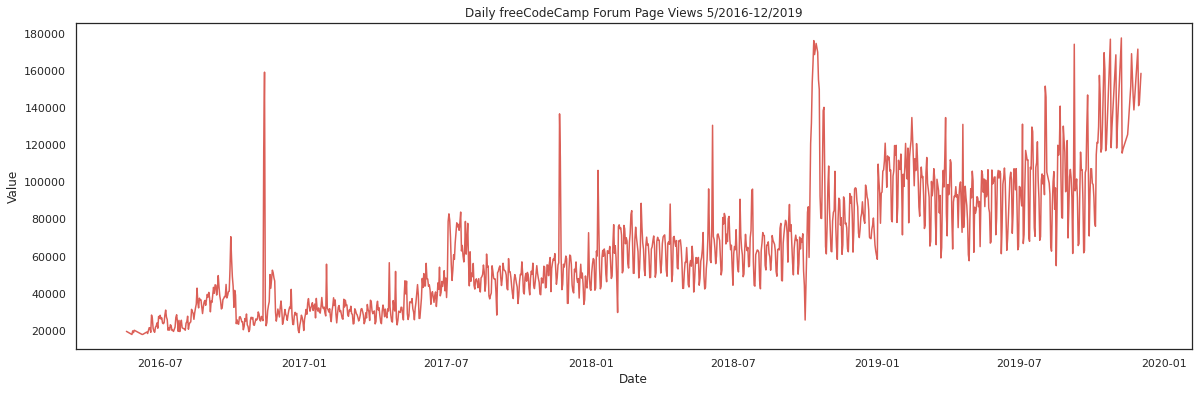

In [7]:
sns.set_theme(style='white')
plt.figure(figsize=(20,6))
plt.title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
plt.ylabel('Value')
plt.xlabel('Date')
sns.lineplot(data=df_month,legend=None,palette='hls')
plt.show()

In [21]:
df_c

,date,value
10,2016-05-19,19736
17,2016-05-26,18060
18,2016-05-27,19997
19,2016-05-28,19044
20,2016-05-29,20325
...,...,...
1294,2019-11-24,138875
1299,2019-11-29,171584
1300,2019-11-30,141161
1301,2019-12-01,142918


In [9]:

df_plot2 = df_c.copy()
df_plot2.reset_index(inplace=True)
df_plot2['Year'] = [d.year for d in df_plot2.date]
df_plot2['month'] = [d.month for d in df_plot2.date]
df_plot2['Month'] = [d.strftime('%b') for d in df_plot2.date]
df_plot2



,index,date,value,Year,month,Month
0,10,2016-05-19,19736,2016,5,May
1,17,2016-05-26,18060,2016,5,May
2,18,2016-05-27,19997,2016,5,May
3,19,2016-05-28,19044,2016,5,May
4,20,2016-05-29,20325,2016,5,May
...,...,...,...,...,...,...
1233,1294,2019-11-24,138875,2019,11,Nov
1234,1299,2019-11-29,171584,2019,11,Nov
1235,1300,2019-11-30,141161,2019,11,Nov
1236,1301,2019-12-01,142918,2019,12,Dec


In [10]:
df_bar = df_plot2[['value','Year','Month']]

In [ ]:
bar_group  = df_bar.groupby(['Year','Month']).mean()
bar_group.reset_index(inplace=True)
bar_group

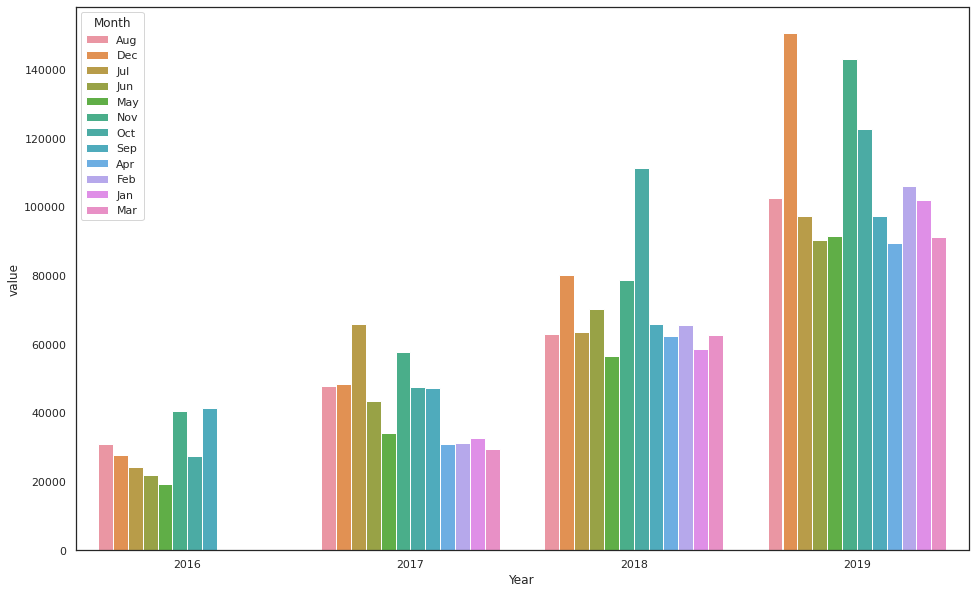

In [22]:
plt.figure(figsize=(16,10))
sns.barplot(x='Year', y='value',hue='Month', data=bar_group)

In [ ]:
df_box = df_plot2[['value','Year','Month','month']]
df_box

In [ ]:
box_group = df_box.groupby(['Year','Month']).mean()
box_group.reset_index(inplace=True)
box_group.sort_values(by='Month',inplace=True)
box_group

In [ ]:
box_group.sort_values(by='month', inplace=True)
box_group

Text(0, 0.5, 'Value')

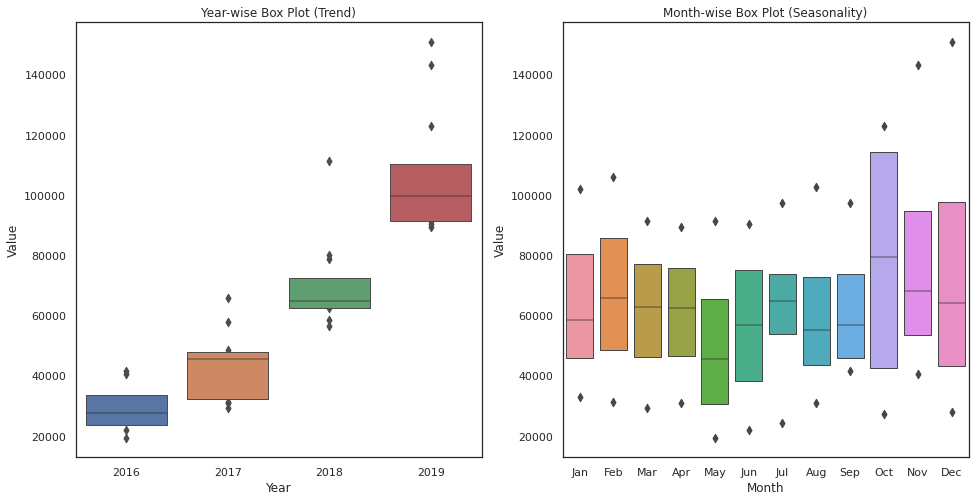

In [16]:
plot_objects = plt.subplots(nrows=1,ncols=2, figsize=(16,8))
fig, (ax1, ax2) = plot_objects

sns.boxenplot(x='Year', y='value',data=box_group, ax=ax1)
ax1.set_title('Year-wise Box Plot (Trend)')
ax1.set_ylabel('Value')

sns.boxenplot(x='Month', y='value',data=box_group, ax=ax2)
ax2.set_title('Month-wise Box Plot (Seasonality)')
ax2.set_ylabel('Value')

In [17]:
sns.boxenplot(x='Year', y='value',data=box_group, ax=ax1)

In [18]:
# df_plot2['date'] = pd.to_datetime(df_plot2['date'],format='%Y%m' )
# group = df_plot2.groupby(pd.Grouper(key='date',freq='MS'))

# df_plot2['month'] = df_plot2['date'].dt.strftime('%Y-%m')
# df_plot2['year'] = df_plot2['date'].dt.strftime('%Y')


In [19]:
# group = df_plot2.melt(id_vars='year',var_name='var',value_name='value')

In [20]:
# df_original.groupby(pd.Grouper(key='Date',freq='M')).sum()